In [16]:
import numpy as np
import h5py
import torch
from score_models import NCSNpp
import torch.nn.functional as F
import os, re, json
from scope.definitions import DEVICE
from glob import glob
from astropy.visualization import ImageNormalize, LogStretch, SqrtStretch

from astropy.io import fits
from functorch import vjp, vmap
from tqdm import tqdm
import matplotlib.pyplot as plt

In [2]:
def load_model(checkpoint_dir, architecture=NCSNpp):
    model_name = os.path.split(checkpoint_dir)[-1]
    with open(os.path.join(checkpoint_dir, "model_hparams.json"), "r") as f:
        hyperparameters = json.load(f)
    model = architecture(**hyperparameters).to(DEVICE)
    paths = glob(os.path.join(checkpoint_dir, "checkpoint*.pt"))
    checkpoints = [int(re.findall('[0-9]+', os.path.split(path)[-1])[-1]) for path in paths]
    model.eval()
    for p in model.parameters(): p.requires_grad = False  # being extra careful for some reasons
    model.load_state_dict(torch.load(paths[np.argmax(checkpoints)], map_location=DEVICE))
    print(f"Loaded checkpoint {max(checkpoints)} of {model_name}")
    return model

In [3]:
skirt_data_path = "/home/aadam/scratch/skirt512_grizy.h5"
probes_data_path = "/home/aadam/projects/rrg-lplevass/probes.h5"

slic_checkpoint_dir = "/home/aadam/scratch/DeblendingGalaxies/models/ncsnpp_hst_noise_psf_f814w_wfc3uv_230421041030"
skirt_prior_checkpoint_dir = "/home/aadam/scratch/DeblendingGalaxies/models/ncsnpp_skirt_g_230415205127"
probes_prior_checkpoint_dir = "/home/aadam/projects/rrg-lplevass/data/score_models/ncsnpp_ct_g_220912024942"

In [4]:
slic_model = load_model(slic_checkpoint_dir)
prior_model = load_model(skirt_prior_checkpoint_dir)
prior_model = load_model(probes_prior_checkpoint_dir)

Loaded checkpoint 139 of ncsnpp_hst_noise_psf_f814w_wfc3uv_230421041030
Loaded checkpoint 30 of ncsnpp_skirt_g_230415205127
Loaded checkpoint 554 of ncsnpp_ct_g_220912024942


In [5]:
def interpolate(image, coordinates):
    """
    Interpolation function, without a batch size. To make it batched, used vmap from functorch.
    """
    C, H, W = image.shape
    x, y = torch.tensor_split(coordinates, 2, dim=0)
    x = x.view(-1)
    y = y.view(-1)
    x0 = torch.floor(x).long()
    x1 = x0 + 1
    y0 = torch.floor(y).long()
    y1 = y0 + 1

    x0 = torch.clip(x0, 0, W - 1)
    x1 = torch.clip(x1, 0, W - 1)
    y0 = torch.clip(y0, 0, H - 1)
    y1 = torch.clip(y1, 0, H - 1)
    x = torch.clip(x, 0, W - 1)
    y = torch.clip(y, 0, H - 1)

    Ia = image[..., x0, y0]
    Ib = image[..., x0, y1]
    Ic = image[..., x1, y0]
    Id = image[..., x1, y1]

    wa = (x1 - x) * (y1 - y)
    wb = (x1 - x) * (y - y0)
    wc = (x - x0) * (y1 - y)
    wd = (x - x0) * (y - y0)

    _, new_H, new_W = coordinates.shape
    return (wa * Ia + wb * Ib + wc * Ic + wd * Id).view(C, new_H, new_W)

In [6]:
psf_file = "/home/aadam/scratch/DeblendingGalaxies/data/F814w_WFC3UV_cropped_psf.fits"
with fits.open(psf_file) as data:
    psf = data["PRIMARY"].data[None].astype(np.float32) # add the channel dimension, a single channel for now.

In [7]:
sigma_min = prior_model.sde.sigma_min
sigma_max = prior_model.sde.sigma_max

def sigma(t): # scale of the marginal prob. distiribution
    return sigma_min * (sigma_max / sigma_min)**t.view(-1, 1, 1, 1)
def g(t): # diffusion coefficient of the VESDE
    return sigma(t) * np.sqrt(2 * (np.log(sigma_max) - np.log(sigma_min)))

In [8]:
def preprocess_probes_g_channel(img):  # channel 0
    img = torch.clamp(img, 0, 1.48)
    img = 2 * img / 1.48 - 1.
    return img


In [30]:
def link_function(x):
    return (x + 1) / 2.

# with h5py.File("/home/aadam/projects/rrg-lplevass/data/probes.h5") as hf:
    # source = hf["galaxies"][101, ..., 0]
# source = preprocess_probes_g_channel(torch.tensor(source).to(DEVICE).view(1, 1, *source.shape))

exptime = 2028
path = "/home/aadam/scratch/DeblendingGalaxies/data/connors_target1.fits"
data = fits.open(path)
data.info()

Filename: /home/aadam/scratch/DeblendingGalaxies/data/connors_target1.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      27   (64, 64)   int16 (rescales to uint16)   
  1                1 ImageHDU        28   (64, 64)   int16 (rescales to uint16)   
  2                1 ImageHDU        28   (64, 64)   int16 (rescales to uint16)   
  3                1 ImageHDU        28   (64, 64)   int16 (rescales to uint16)   


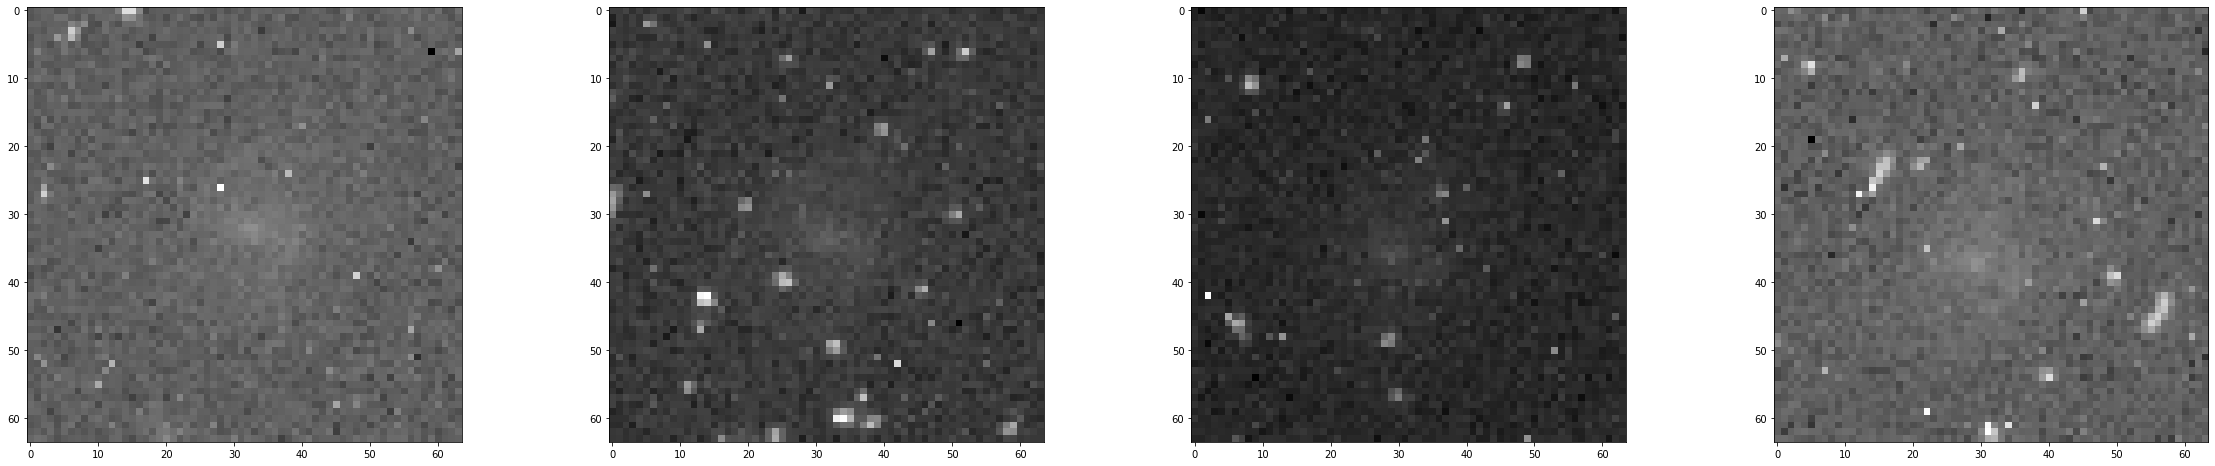

In [31]:
fig, axs = plt.subplots(1, 4, figsize=(40, 8))
for i in range(4):
    axs[i].imshow(data[i].data / exptime, cmap="gray", norm=ImageNormalize(stretch=LogStretch()))

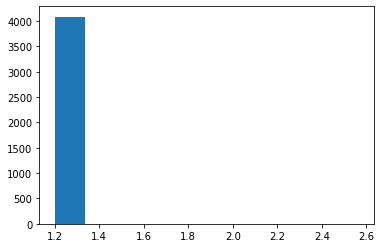

In [32]:
plt.hist(data[0].data.ravel()/ exptime);

In [33]:
(data[0].data / exptime).min()

1.20069033530572

In [42]:
observation_pixels = 64
observation_pixel_size = 0.04
super_sampling_factor = 4
model_pixel_size = 0.01
model_pixels = 256
zero_padding = 0

def make_forward_model(psf):
    C, H, W = psf.shape
    psf = torch.tensor(psf).to(DEVICE).view(C, 1, H, W) # reshape to a convolution kernel [channel_out, channels_in/groups, H, W]
    batched_interpolation = vmap(interpolate, in_dims=(0, None))  # only batch over the images

    # TODO support a shift of the ccordinates
    # define target coordinates at the super sampling resolution of the psf

    
    fov = observation_pixel_size * observation_pixels
    x = torch.linspace(-1, 1, super_sampling_factor*observation_pixels).float() * fov / 2
    x, y = torch.meshgrid(x, x, indexing="ij")  # TODO make this coherent with WCS
    # Transform these coordinates into model pixel indices
    _min = - model_pixel_size * (model_pixels + zero_padding) / 2
    i_coord = (x - _min) / model_pixel_size
    j_coord = (y - _min) / model_pixel_size
    coordinates = torch.stack([i_coord, j_coord], dim=0).to(DEVICE)
    def A(x):
        x = F.pad(x, pad=[zero_padding]*4, mode="constant", value=0.)
        x = batched_interpolation(x, coordinates)
        x = F.conv2d(x, psf, groups=C, padding="same")
        x = F.avg_pool2d(x, kernel_size=super_sampling_factor, stride=super_sampling_factor)
        return x
    return A


In [14]:
# HST WFC3 UVIS F814W
photflam = 1.4980e-19	
photplam = 8039.1 # angstrom
minimum_count = 0.
LOG10 = np.log(10.)

def ab_mag_to_jansky_per_arcsec_squared(img):
    return 10**(-(img - 8.9) / 2.5)

def electron_count_to_ab_mag(img):
    """
    Assumes img is a torch tensor, expressed in electron / sec units.

    photflam and photplam are usually found in HST fits file headers, and refer to the
    inverse sensitivity (in erg/cm^2/sec/Angstrom) and the pivot wavelength respectively.
    See https://hst-docs.stsci.edu/acsdhb/chapter-5-acs-data-analysis/5-1-photometry.

    """
    zero_point = -2.5* np.log10(photflam) - 21.10 - 5 * np.log10(photplam) + 18.6921
    return -2.5 * torch.log(torch.maximum(torch.ones_like(img) * minimum_count, img)) / LOG10 + zero_point

def ab_mag_to_jansky_per_arcsec_squared(img):
    return 10**(-(img - 8.9) / 2.5)

def hst_observation_preprocessing(img):
    img = electron_count_to_ab_mag(img)
    img = 1e6 * ab_mag_to_jansky_per_arcsec_squared(img) # convert to micro Jansky / arcsec^2
    return img

def preprocessing(img, dynamic_range=1e5):
    img = ab_mag_to_jansky_per_arcsec_squared(img)
    return torch.log(1e6 * img + 1/dynamic_range) / np.log(10.) + np.log10(dynamic_range)

def inverse_preprocessing(img, dynamic_range=1e5):
    return 10**(img - np.log10(dynamic_range))

In [80]:
def convolved_likelihood_gradient(x, t):
    y_hat, vjpfunc = vjp(lambda x: forward_model(link_function(x)), x)
    score = slic_model.score(observation - y_hat, t)
    grad = vjpfunc(score)[0]
    return -grad

def link_function(x):
    return (x + 1) / 2.
# We diffuse in x space, so make sure to go back to xi space when going in score model
def score_fn(x, t):
    B, *D = x.shape
    prior_score = prior_model(x, t) / sigma(t).view(B, *[1]*len(D))
    likelihood_score = convolved_likelihood_gradient(x, t)
    return prior_score + 2000*likelihood_score


In [81]:
# Note that diffusion is written in term of xi, so we only put the Jacobian in the likelihood term. This is easier than diffusing in x after some thought.
def euler_maruyama_step(x, t, dt):
    t += dt
    x_mean = x - (g(t)**2 * score_fn(x, t)) * dt
    z = torch.randn_like(x)
    x = x_mean + g(t) * z * np.sqrt(-dt)
    return x_mean, x, t

In [82]:
B = 12
N = 2000
with torch.no_grad():
    dt = -1. / N
    t = torch.ones(B).to(DEVICE)
    x = torch.randn(B, 1, model_pixels, model_pixels).to(DEVICE) * sigma(t) # TODO add channels
    for _ in tqdm(range(N)):
        x_mean, x, t = euler_maruyama_step(x, t, dt)

100%|██████████| 2000/2000 [21:45<00:00,  1.53it/s]


In [ ]:
fig, axs = plt.subplots(2, 6, figsize=(24, 8))
y_hat = forward_model(x_mean)

axs[0, 0].imshow(ground_truth.cpu().squeeze(), cmap="magma")
axs[0, 0].axis("off")
axs[1, 0].imshow(observation.cpu().squeeze(), cmap="magma", vmax=5)
axs[1, 0].axis("off")
for j in range(5):
    axs[0, j+1].imshow(x_mean[j].cpu().squeeze(), cmap="magma")
    axs[0, j+1].axis("off")
    axs[1, j+1].imshow(y_hat[j].cpu().squeeze(), cmap="magma", vmax=5)
    axs[1, j+1].axis("off")
plt.subplots_adjust(hspace=0, wspace=0)

# Probes test with link function

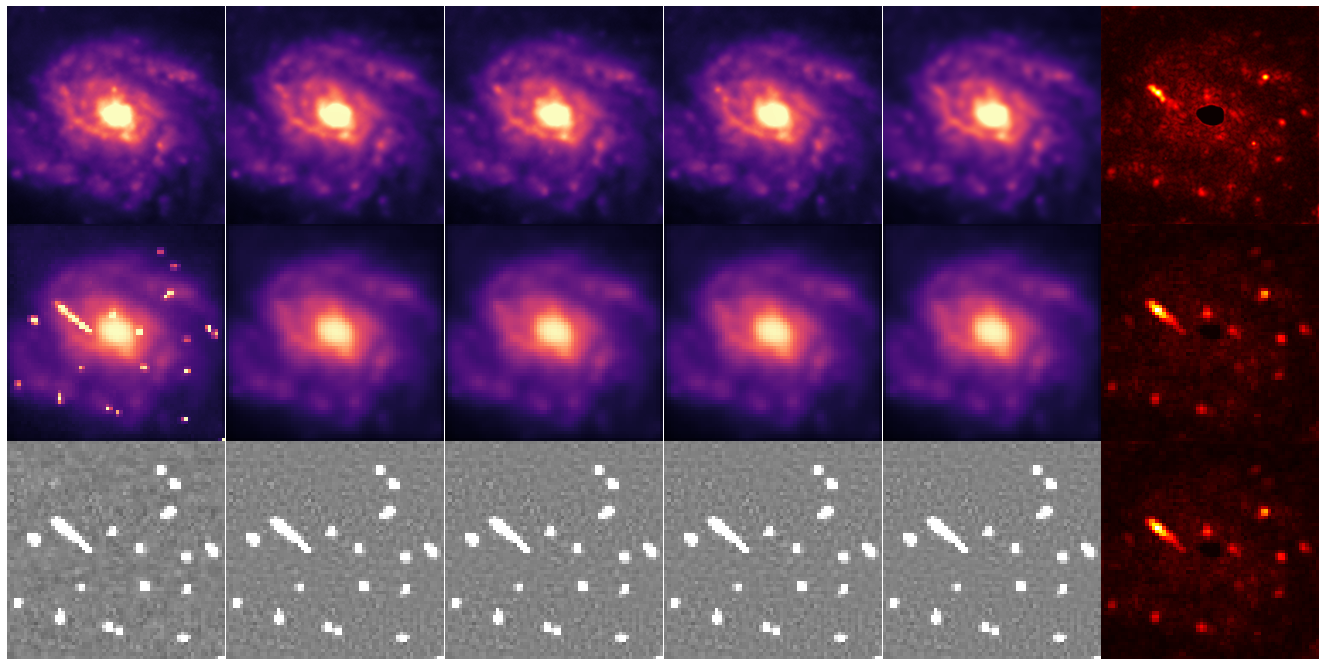

In [ ]:
# statistics
# fudge factor = 1000
fig, axs = plt.subplots(3, 6, figsize=(24, 12))
y_hat = forward_model(link_function(x_mean))

axs[0, 0].imshow(link_function(source).cpu().squeeze(), cmap="magma", vmin=0, vmax=1)
axs[0, 0].axis("off")
axs[1, 0].imshow(observation.cpu().squeeze(), cmap="magma", vmin=0, vmax=1)
axs[1, 0].axis("off")
axs[2, 0].imshow(noise_map.cpu().squeeze(),  cmap="gray", vmin=-0.04, vmax=0.08)
axs[2, 0].axis("off")
for j in range(3):
    axs[0, j+1].imshow(link_function(x_mean[j]).cpu().squeeze(), cmap="magma", vmin=0, vmax=1)
    axs[0, j+1].axis("off")
    axs[1, j+1].imshow(y_hat[j].cpu().squeeze(), cmap="magma", vmin=0, vmax=1)
    axs[1, j+1].axis("off")
    axs[2, j+1].imshow((observation - y_hat[j]).cpu().squeeze(), cmap="gray", vmin=-0.04, vmax=0.08)
    axs[2, j+1].axis("off")
    
    axs[0, -2].imshow(link_function(x_mean.mean(dim=0)).cpu().squeeze(), cmap="magma", vmin=0, vmax=1)
    axs[0, -2].axis("off")
    axs[1, -2].imshow(y_hat.mean(dim=0).cpu().squeeze(), cmap="magma", vmin=0, vmax=1)
    axs[1, -2].axis("off")
    axs[2, -2].imshow((observation - y_hat).mean(dim=0).cpu().squeeze(), cmap="gray", vmin=-0.04, vmax=0.08)
    axs[2, -2].axis("off")
    
    axs[0, -1].imshow(link_function(x_mean.std(dim=0)).cpu().squeeze(), cmap="hot")
    axs[0, -1].axis("off")
    axs[1, -1].imshow(y_hat.std(dim=0).cpu().squeeze(), cmap="hot")
    axs[1, -1].axis("off")
    axs[2, -1].imshow((observation - y_hat).std(dim=0).cpu().squeeze(), cmap="hot")
    axs[2, -1].axis("off")
plt.subplots_adjust(hspace=0, wspace=-0.107)